CONNECTED TO: /content/OnePiece-Bounty - Sheet1.csv
Shape: (165, 3)
Columns: ['S.no', 'Name ', 'Bounty']

First 5 rows:
   S.no             Name           Bounty
0     1      Gol D. Roger  ฿5,564,800,000
1     2    Edward Newgate  ฿5,046,000,000
2     3            Kaidou  ฿4,611,100,000
3     4  Charlotte Linlin  ฿4,388,000,000
4     5            Shanks  ฿4,048,900,000

Last 5 rows:
     S.no       Name    Bounty
160   999  Vasco Shot  Unknown
161   999       Vista  Unknown
162   999      Yasopp  Unknown
163   999       Yorki  Unknown
164   999        Zeff  Unknown

Dtypes:
S.no       int64
Name      object
Bounty    object

Raw Bounty samples: ['฿300,000,000', '฿293,000,000', 'Unknown', '฿100,000,000', 'Unknown']
Unknown bounties in raw file: 20
Rows with S.no = 999: 20
Non-Berry symbols: [['Mikio Itoo', '¥1,000,000']]
------------------------------------------------------------
[01] Load raw data                  rows=165  nulls=0   | columns=['S.no', 'Name ', 'Bounty']
[02] Standard

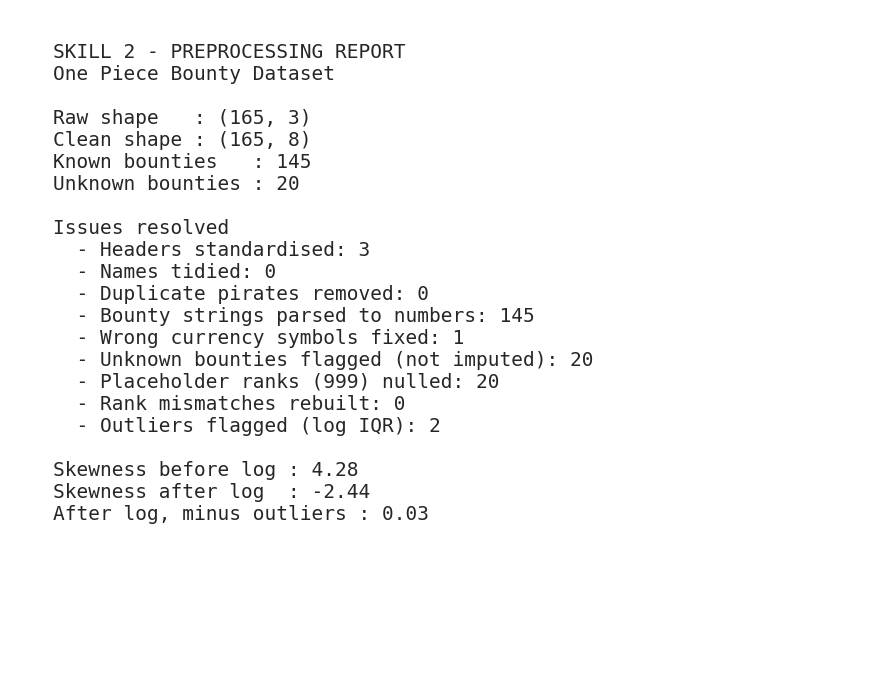

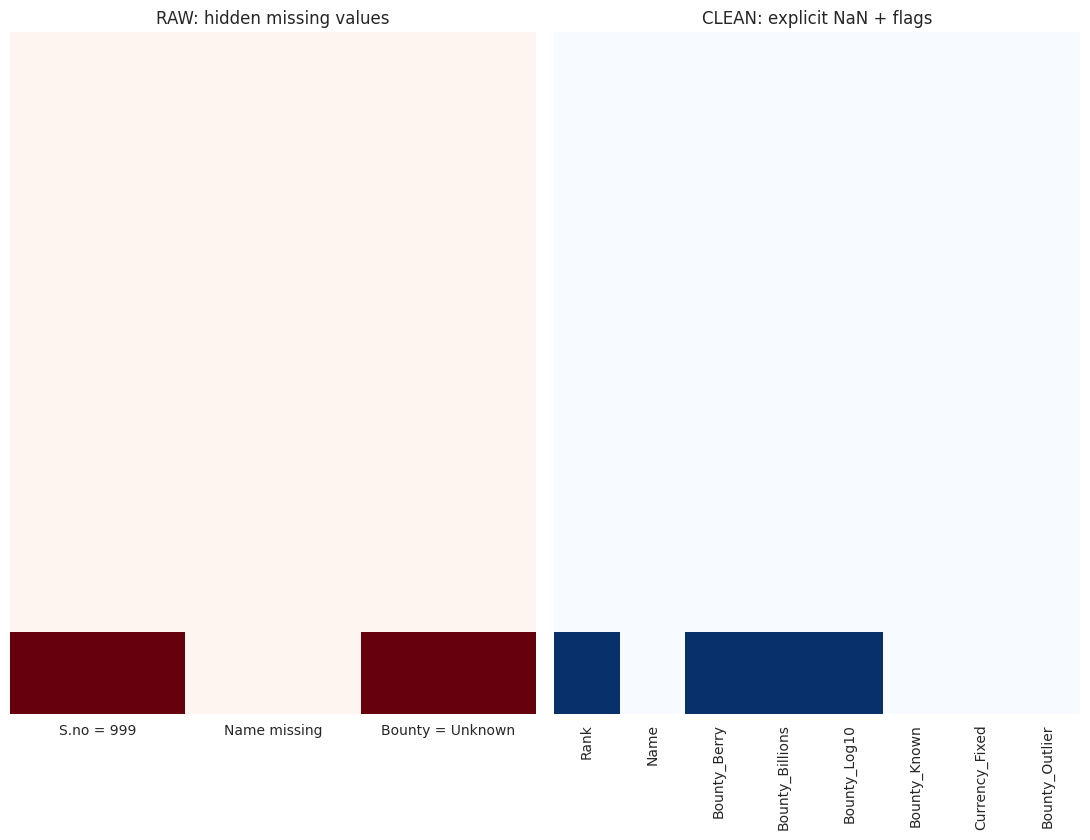

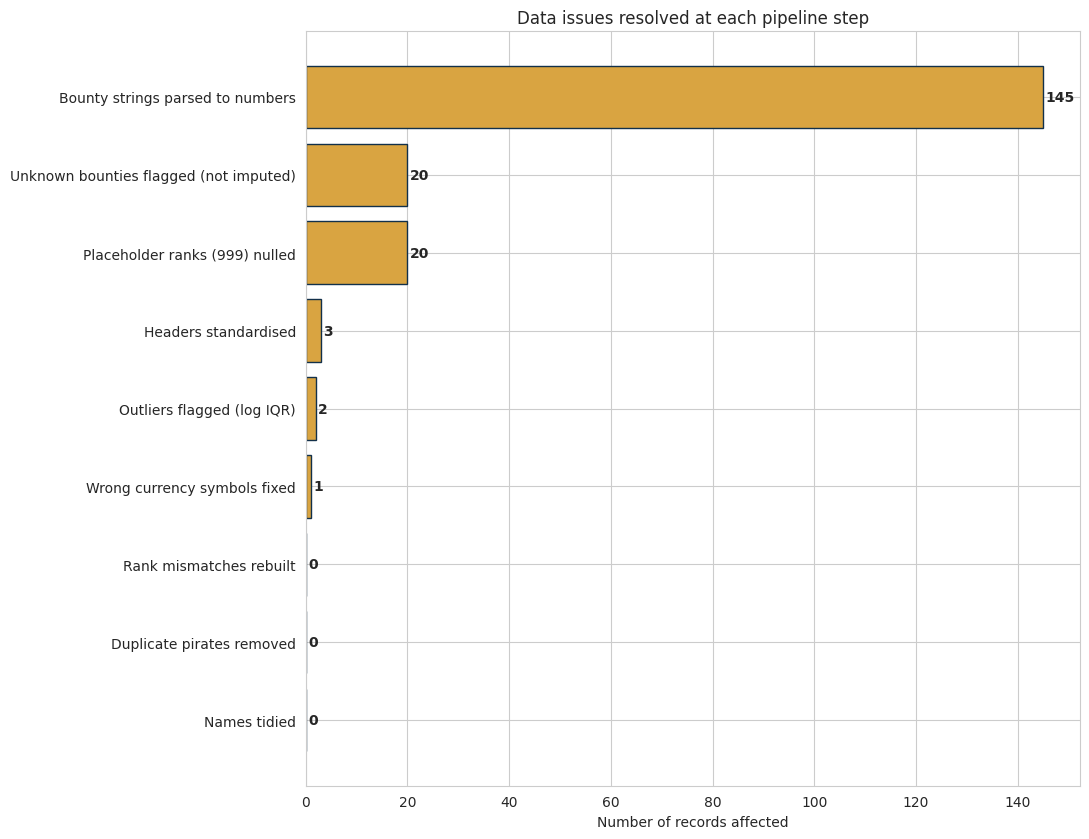

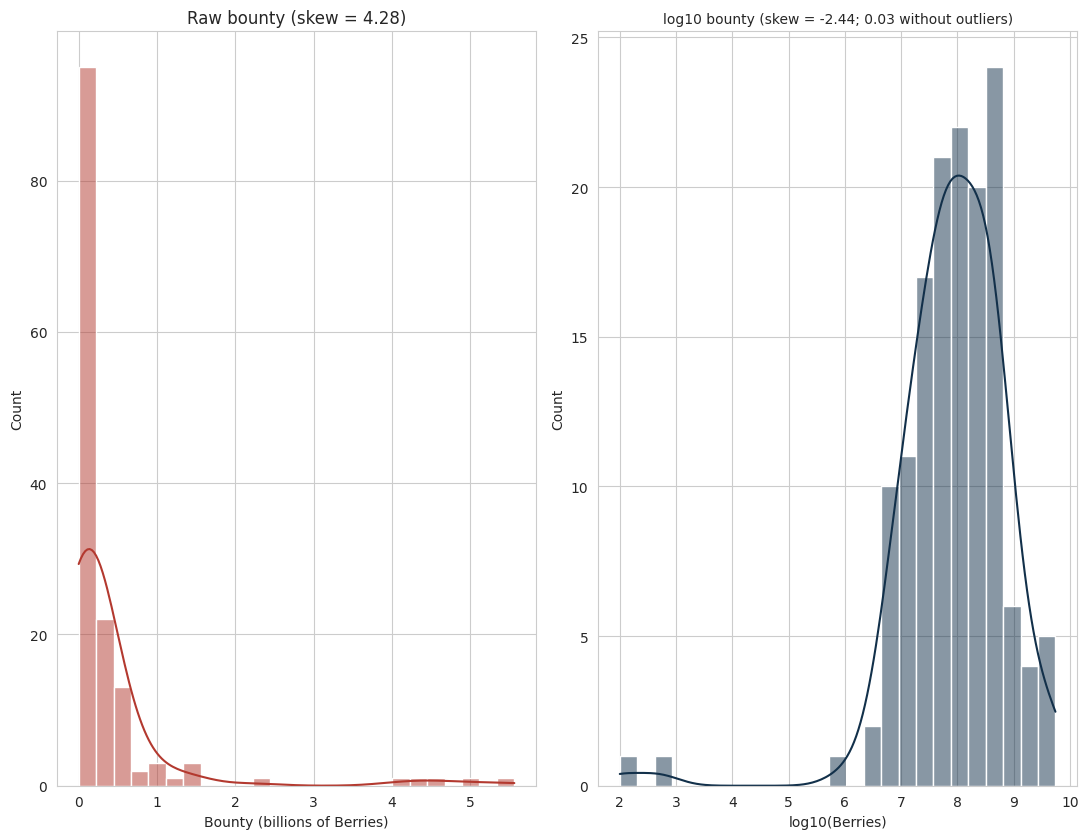

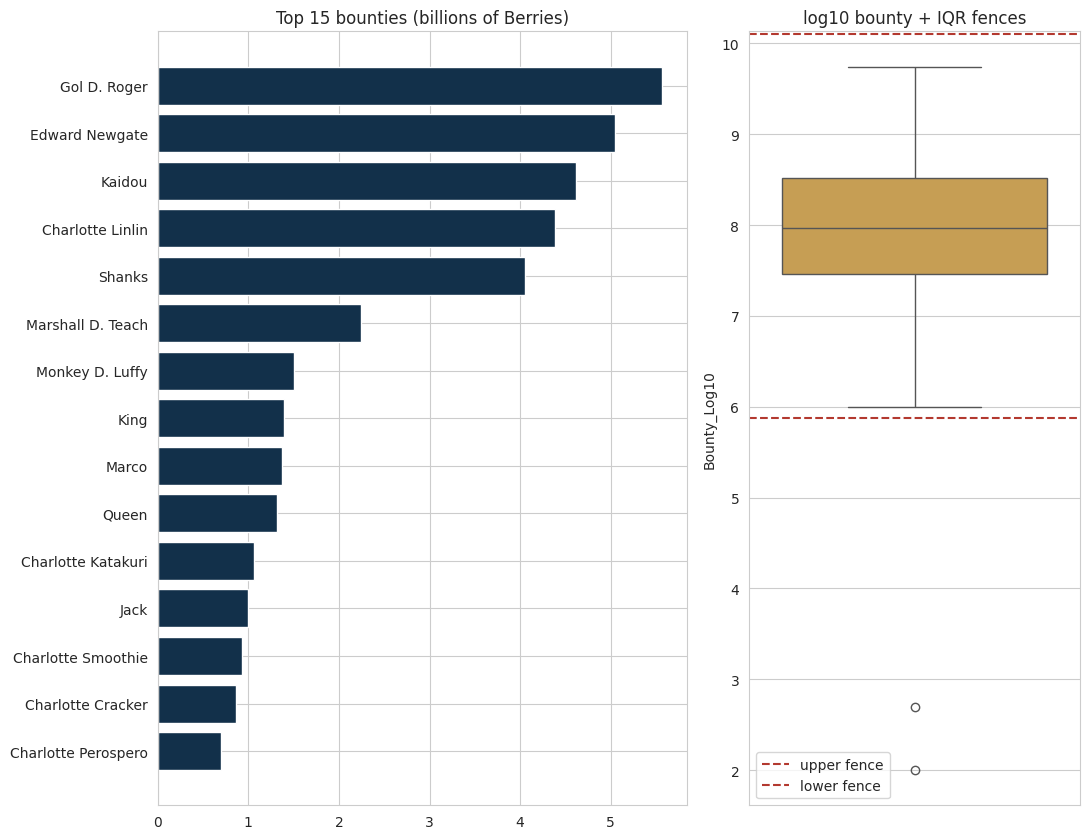

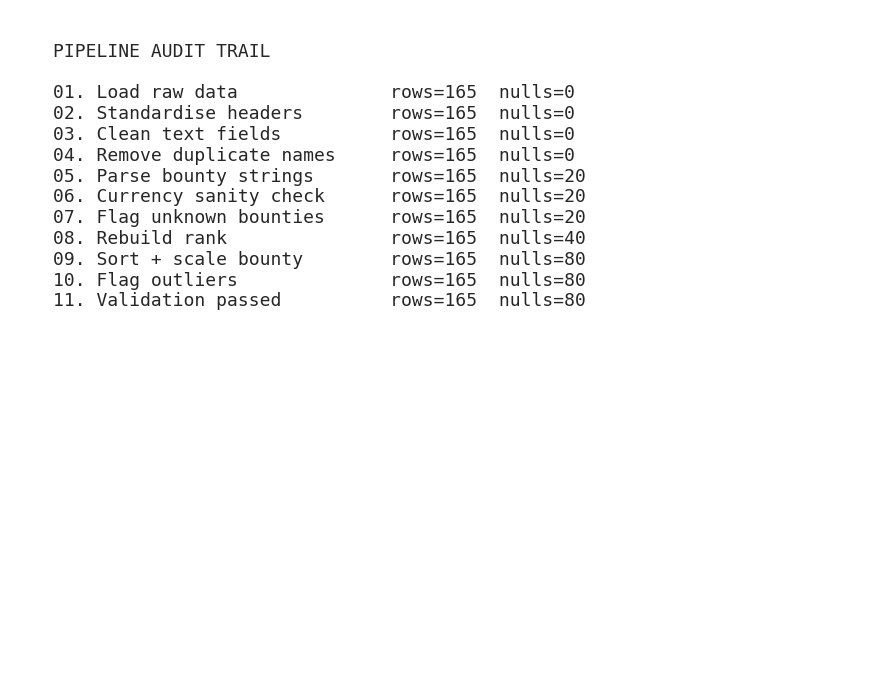


Files created in Skill2_Output
  - Observation_Skill_2.txt
  - cleaned_onepiece_bounty.csv
  - data_dictionary.md
  - preprocessing_report.pdf
  - quality_report.json
  - wanted_board.html


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [6]:
import importlib.util, subprocess, sys

for pkg in ["pandas", "numpy", "matplotlib", "seaborn"]:
    if importlib.util.find_spec(pkg) is None:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])

import os, re, json, glob, warnings, unicodedata
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.backends.backend_pdf import PdfPages

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")

CSV_NAME = "OnePiece-Bounty_-_Sheet1.csv"
CSV_PATH = "/content/OnePiece-Bounty_-_Sheet1.csv"
OUT_DIR = "Skill2_Output"
os.makedirs(OUT_DIR, exist_ok=True)

def find_csv():
    if os.path.exists(CSV_PATH):
        return CSV_PATH
    roots = ["/content", "/content/drive", os.getcwd(), "/mnt/user-data/uploads"]
    for root in roots:
        for path in glob.glob(os.path.join(root, "**", "*.csv"), recursive=True):
            if "bounty" in os.path.basename(path).lower() and "/sample_data/" not in path:
                return path
    try:
        from google.colab import files
        print("CSV not found on disk - pick OnePiece-Bounty_-_Sheet1.csv in the upload dialog")
        uploaded = files.upload()
        for name in uploaded:
            if name.lower().endswith(".csv"):
                return os.path.abspath(name)
    except ImportError:
        pass
    raise FileNotFoundError("Could not find the One Piece bounty CSV. Set CSV_PATH at the top to its exact path.")

LOG = []
ISSUES = {}

def log(step, df, note=""):
    LOG.append({"step": step, "rows": int(len(df)), "cols": int(df.shape[1]),
                "nulls": int(df.isna().sum().sum()), "note": note})
    print(f"[{len(LOG):02d}] {step:<30} rows={len(df):<4} nulls={int(df.isna().sum().sum()):<3} | {note}")


FOUND_PATH = find_csv()
raw = pd.read_csv(FOUND_PATH)
print("CONNECTED TO:", FOUND_PATH)
print("Shape:", raw.shape)
print("Columns:", list(raw.columns))
print("\nFirst 5 rows:")
print(raw.head().to_string())
print("\nLast 5 rows:")
print(raw.tail().to_string())
print("\nDtypes:")
print(raw.dtypes.to_string())
print("\nRaw Bounty samples:", raw["Bounty"].sample(5, random_state=1).tolist())
print("Unknown bounties in raw file:", int(raw["Bounty"].str.strip().str.lower().eq("unknown").sum()))
print("Rows with S.no = 999:", int((raw["S.no"] == 999).sum()))
print("Non-Berry symbols:", raw.loc[~raw["Bounty"].str.contains("\u0e3f|Unknown"), ["Name ", "Bounty"]].values.tolist())
print("-" * 60)
df = raw.copy()
log("Load raw data", df, f"columns={list(raw.columns)}")

old_cols = list(df.columns)
df.columns = df.columns.str.strip()
df = df.rename(columns={"S.no": "Source_Rank", "Name": "Name", "Bounty": "Bounty_Raw"})
ISSUES["Headers standardised"] = sum(a != b for a, b in zip(old_cols, df.columns))
log("Standardise headers", df, f"{old_cols} -> {list(df.columns)}")

before = df["Name"].copy()
df["Name"] = (df["Name"].astype(str)
              .map(lambda s: unicodedata.normalize("NFKC", s))
              .str.replace(r"\s+", " ", regex=True).str.strip())
df["Bounty_Raw"] = df["Bounty_Raw"].astype(str).str.strip()
ISSUES["Names tidied"] = int((before != df["Name"]).sum())
log("Clean text fields", df, f"names changed={ISSUES['Names tidied']}")

dups = int(df.duplicated(subset="Name").sum())
df = df.drop_duplicates(subset="Name", keep="first").reset_index(drop=True)
ISSUES["Duplicate pirates removed"] = dups
log("Remove duplicate names", df, f"duplicates removed={dups}")

UNKNOWN_TOKENS = {"unknown", "", "nan", "-", "n/a", "none"}

def parse_bounty(text):
    t = str(text).strip()
    if t.lower() in UNKNOWN_TOKENS:
        return pd.Series([np.nan, "UNKNOWN"])
    symbol = re.match(r"^[^\d]*", t).group(0).strip()
    digits = re.sub(r"[^\d]", "", t)
    return pd.Series([float(digits) if digits else np.nan, symbol if symbol else "NONE"])

parsed = df["Bounty_Raw"].apply(parse_bounty)
df["Bounty_Berry"] = parsed[0]
df["Bounty_Symbol"] = parsed[1]
ISSUES["Bounty strings parsed to numbers"] = int(df["Bounty_Berry"].notna().sum())
log("Parse bounty strings", df, f"symbols found={df['Bounty_Symbol'].value_counts().to_dict()}")

BERRY = "\u0e3f"
df["Currency_Fixed"] = ~df["Bounty_Symbol"].isin([BERRY, "UNKNOWN"])
fixed = df.loc[df["Currency_Fixed"], ["Name", "Bounty_Raw"]]
ISSUES["Wrong currency symbols fixed"] = int(df["Currency_Fixed"].sum())
log("Currency sanity check", df, f"fixed={fixed.values.tolist()}")

df["Bounty_Known"] = df["Bounty_Berry"].notna()
ISSUES["Unknown bounties flagged (not imputed)"] = int((~df["Bounty_Known"]).sum())
log("Flag unknown bounties", df, f"unknown={int((~df['Bounty_Known']).sum())}")

expected = df["Bounty_Berry"].rank(method="min", ascending=False)
known_mask = df["Bounty_Known"]
mismatch = int((expected[known_mask] != df.loc[known_mask, "Source_Rank"]).sum())
placeholders = int((df.loc[~known_mask, "Source_Rank"] == 999).sum())
df["Rank"] = expected.astype("Int64")
df = df.drop(columns=["Source_Rank"])
ISSUES["Placeholder ranks (999) nulled"] = placeholders
ISSUES["Rank mismatches rebuilt"] = mismatch
log("Rebuild rank", df, f"old S.no mismatches={mismatch}, 999 placeholders={placeholders}")

df = df.sort_values(["Bounty_Berry", "Name"], ascending=[False, True]).reset_index(drop=True)
df["Bounty_Berry"] = df["Bounty_Berry"].astype("Int64")
df["Bounty_Billions"] = (df["Bounty_Berry"].astype("float64") / 1e9).round(4)
df["Bounty_Log10"] = np.log10(df["Bounty_Berry"].astype("float64")).round(4)
log("Sort + scale bounty", df, "added Bounty_Billions, Bounty_Log10")

lg = df["Bounty_Log10"].dropna()
q1, q3 = lg.quantile(0.25), lg.quantile(0.75)
iqr = q3 - q1
low_f, high_f = q1 - 1.5 * iqr, q3 + 1.5 * iqr
df["Bounty_Outlier"] = (df["Bounty_Log10"] < low_f) | (df["Bounty_Log10"] > high_f)
df["Bounty_Outlier"] = df["Bounty_Outlier"].fillna(False)
ISSUES["Outliers flagged (log IQR)"] = int(df["Bounty_Outlier"].sum())
log("Flag outliers", df, f"fences(log10)=[{low_f:.2f}, {high_f:.2f}] flagged={int(df['Bounty_Outlier'].sum())}")

final_cols = ["Rank", "Name", "Bounty_Berry", "Bounty_Billions", "Bounty_Log10",
              "Bounty_Known", "Currency_Fixed", "Bounty_Outlier"]
clean = df[final_cols].copy()

assert clean["Name"].is_unique, "duplicate names survived"
assert (clean["Bounty_Berry"].dropna() > 0).all(), "non-positive bounty found"
assert clean.loc[clean["Bounty_Known"], "Rank"].notna().all(), "known bounty without rank"
assert clean.loc[~clean["Bounty_Known"], "Bounty_Berry"].isna().all(), "unknown bounty got a value"
assert clean["Bounty_Berry"].dropna().is_monotonic_decreasing, "bounty not sorted"
log("Validation passed", clean, "5 integrity assertions OK")

clean.to_csv(f"{OUT_DIR}/cleaned_onepiece_bounty.csv", index=False)
print("\nCLEANED DATASET PREVIEW")
print(clean.head(10).to_string())
print("\nSHAPE:", raw.shape, "->", clean.shape)

known = clean[clean["Bounty_Known"]]
skew_raw = float(known["Bounty_Berry"].astype("float64").skew())
skew_log = float(known["Bounty_Log10"].skew())
skew_log_trim = float(known.loc[~known["Bounty_Outlier"], "Bounty_Log10"].skew())
low_outliers = known.loc[known["Bounty_Outlier"], "Name"].tolist()
top = known.iloc[0]
total_bounty = float(known["Bounty_Berry"].astype("float64").sum())

report = {
    "dataset": CSV_NAME,
    "rows_raw": int(len(raw)), "rows_clean": int(len(clean)),
    "columns_raw": list(raw.columns), "columns_clean": final_cols,
    "known_bounties": int(len(known)), "unknown_bounties": int((~clean["Bounty_Known"]).sum()),
    "issues_resolved": ISSUES,
    "outlier_fences_log10": {"lower": round(float(low_f), 4), "upper": round(float(high_f), 4)},
    "skewness": {"raw_berry": round(skew_raw, 3), "log10": round(skew_log, 3),
                 "log10_without_outliers": round(skew_log_trim, 3)},
    "outliers": low_outliers,
    "highest_bounty": {"name": top["Name"], "berry": int(top["Bounty_Berry"])},
    "median_known_berry": float(known["Bounty_Berry"].astype("float64").median()),
    "total_known_berry": total_bounty,
    "pipeline_log": LOG,
}
with open(f"{OUT_DIR}/quality_report.json", "w", encoding="utf-8") as f:
    json.dump(report, f, indent=2, ensure_ascii=False)

dictionary = """# Data Dictionary - Cleaned One Piece Bounty Dataset

| Column | Type | Meaning |
|---|---|---|
| Rank | Int | Competition rank by bounty (ties share a rank). Empty when bounty is unknown |
| Name | Text | Character name, whitespace-normalised and unique |
| Bounty_Berry | Int | Bounty in Berries. Empty when unknown (never imputed) |
| Bounty_Billions | Float | Bounty divided by 1e9, for readable axes |
| Bounty_Log10 | Float | log10 of Bounty_Berry, tames the heavy right skew |
| Bounty_Known | Bool | False when the source said Unknown |
| Currency_Fixed | Bool | True when the source used a non-Berry currency symbol that was corrected |
| Bounty_Outlier | Bool | True when Bounty_Log10 lies outside the IQR fences |

Dropped: Source_Rank (S.no), because it was rebuilt from the bounty itself and carried 999 placeholders.
"""
with open(f"{OUT_DIR}/data_dictionary.md", "w", encoding="utf-8") as f:
    f.write(dictionary)

NAVY, GOLD, RED = "#12304a", "#d9a441", "#b3392f"

with PdfPages(f"{OUT_DIR}/preprocessing_report.pdf") as pdf:

    plt.figure(figsize=(11, 8.5)); plt.axis("off")
    text = "SKILL 2 - PREPROCESSING REPORT\nOne Piece Bounty Dataset\n\n"
    text += f"Raw shape   : {raw.shape}\nClean shape : {clean.shape}\n"
    text += f"Known bounties   : {len(known)}\nUnknown bounties : {int((~clean['Bounty_Known']).sum())}\n\n"
    text += "Issues resolved\n"
    for k, v in ISSUES.items():
        text += f"  - {k}: {v}\n"
    text += (f"\nSkewness before log : {skew_raw:.2f}\nSkewness after log  : {skew_log:.2f}"
             f"\nAfter log, minus outliers : {skew_log_trim:.2f}")
    plt.text(0.05, 0.95, text, fontsize=14, va="top", family="monospace")
    pdf.savefig(); plt.show(); plt.close()

    fig, ax = plt.subplots(1, 2, figsize=(11, 8.5))
    hidden = pd.DataFrame({
        "S.no = 999": (raw["S.no"] == 999),
        "Name missing": raw["Name "].isna() if "Name " in raw.columns else raw["Name"].isna(),
        "Bounty = Unknown": raw["Bounty"].str.strip().str.lower().eq("unknown"),
    })
    sns.heatmap(hidden, cbar=False, yticklabels=False, cmap="Reds", ax=ax[0])
    ax[0].set_title("RAW: hidden missing values")
    sns.heatmap(clean.isna(), cbar=False, yticklabels=False, cmap="Blues", ax=ax[1])
    ax[1].set_title("CLEAN: explicit NaN + flags")
    plt.tight_layout(); pdf.savefig(); plt.show(); plt.close()

    plt.figure(figsize=(11, 8.5))
    s = pd.Series(ISSUES).sort_values()
    plt.barh(s.index, s.values, color=GOLD, edgecolor=NAVY)
    for i, v in enumerate(s.values):
        plt.text(v + 0.5, i, str(v), va="center", fontweight="bold")
    plt.title("Data issues resolved at each pipeline step")
    plt.xlabel("Number of records affected")
    plt.tight_layout(); pdf.savefig(); plt.show(); plt.close()

    fig, ax = plt.subplots(1, 2, figsize=(11, 8.5))
    sns.histplot(known["Bounty_Billions"].astype(float), bins=25, kde=True, color=RED, ax=ax[0])
    ax[0].set_title(f"Raw bounty (skew = {skew_raw:.2f})")
    ax[0].set_xlabel("Bounty (billions of Berries)")
    sns.histplot(known["Bounty_Log10"].astype(float), bins=25, kde=True, color=NAVY, ax=ax[1])
    ax[1].set_title(f"log10 bounty (skew = {skew_log:.2f}; {skew_log_trim:.2f} without outliers)", fontsize=10)
    ax[1].set_xlabel("log10(Berries)")
    plt.tight_layout(); pdf.savefig(); plt.show(); plt.close()

    fig, ax = plt.subplots(1, 2, figsize=(11, 8.5), gridspec_kw={"width_ratios": [1.6, 1]})
    t15 = known.head(15).iloc[::-1]
    ax[0].barh(t15["Name"], t15["Bounty_Billions"].astype(float), color=NAVY)
    ax[0].set_title("Top 15 bounties (billions of Berries)")
    sns.boxplot(y=known["Bounty_Log10"].astype(float), color=GOLD, ax=ax[1])
    ax[1].axhline(high_f, color=RED, ls="--", label="upper fence")
    ax[1].axhline(low_f, color=RED, ls="--", label="lower fence")
    ax[1].set_title("log10 bounty + IQR fences"); ax[1].legend()
    plt.tight_layout(); pdf.savefig(); plt.show(); plt.close()

    plt.figure(figsize=(11, 8.5)); plt.axis("off")
    text = "PIPELINE AUDIT TRAIL\n\n"
    for i, e in enumerate(LOG, 1):
        text += f"{i:02d}. {e['step']:<26} rows={e['rows']:<4} nulls={e['nulls']}\n"
    plt.text(0.05, 0.95, text, fontsize=13, va="top", family="monospace")
    pdf.savefig(); plt.show(); plt.close()

cards = []
for _, r in clean.iterrows():
    cards.append({
        "name": r["Name"],
        "rank": None if pd.isna(r["Rank"]) else int(r["Rank"]),
        "berry": None if pd.isna(r["Bounty_Berry"]) else int(r["Bounty_Berry"]),
        "outlier": bool(r["Bounty_Outlier"]),
        "fixed": bool(r["Currency_Fixed"]),
    })
payload = {"cards": cards, "total": total_bounty, "known": int(len(known)),
           "unknown": int((~clean["Bounty_Known"]).sum()), "top": top["Name"],
           "topBerry": int(top["Bounty_Berry"])}

HTML = r"""<!DOCTYPE html><html lang="en"><head><meta charset="utf-8">
<meta name="viewport" content="width=device-width,initial-scale=1">
<title>Grand Line Wanted Board</title><style>
:root{--sea:#08131f;--sea2:#10304a;--paper:#f0dfb2;--ink:#3b2412;--gold:#d9a441;--red:#b3392f}
*{box-sizing:border-box}body{margin:0;background:radial-gradient(circle at 20% 0,var(--sea2),var(--sea) 60%) fixed;color:#f5ecd2;font-family:Georgia,'Palatino Linotype',serif}
header{padding:42px 20px 10px;text-align:center}
h1{margin:0;font-size:clamp(30px,6vw,60px);letter-spacing:6px;color:var(--gold);text-shadow:0 3px 0 #000}
.sub{opacity:.75;letter-spacing:3px;font-size:13px}
.kpis{display:flex;flex-wrap:wrap;gap:14px;justify-content:center;margin:26px auto;max-width:1000px}
.kpi{background:#0d2538;border:1px solid #2a4b66;border-radius:12px;padding:14px 22px;min-width:150px;text-align:center}
.kpi b{display:block;font-size:26px;color:var(--gold)}.kpi span{font-size:12px;letter-spacing:2px;opacity:.7}
.bar{display:flex;flex-wrap:wrap;gap:10px;justify-content:center;padding:0 16px 22px}
input,select,button{background:#0d2538;color:#f5ecd2;border:1px solid #2a4b66;border-radius:8px;padding:10px 14px;font:inherit}
button.on{background:var(--gold);color:#1b1206;font-weight:bold}
.grid{display:grid;grid-template-columns:repeat(auto-fill,minmax(210px,1fr));gap:26px;max-width:1300px;margin:0 auto;padding:10px 24px 70px}
.poster{position:relative;background:var(--paper);color:var(--ink);padding:16px 14px 18px;text-align:center;border:3px solid #7a5230;border-radius:4px;
box-shadow:0 10px 24px #000a;transform:rotate(var(--r));transition:.25s;background-image:radial-gradient(#0000 60%,#7a52301f 100%)}
.poster:hover{transform:rotate(0) translateY(-8px) scale(1.04);z-index:2}
.wanted{font-size:26px;font-weight:bold;letter-spacing:5px;border-bottom:2px solid var(--ink);padding-bottom:4px}
.pic{height:120px;margin:12px 0;border:2px solid var(--ink);display:flex;align-items:center;justify-content:center;font-size:54px;font-weight:bold;
background:repeating-linear-gradient(45deg,#d8c690,#d8c690 8px,#cdbb82 8px,#cdbb82 16px)}
.name{font-size:17px;font-weight:bold;text-transform:uppercase;min-height:44px;display:flex;align-items:center;justify-content:center}
.doa{font-size:11px;letter-spacing:3px;margin:2px 0 8px}
.money{font-size:21px;font-weight:bold}
.seal{position:absolute;top:-14px;right:-12px;width:46px;height:46px;border-radius:50%;background:var(--red);color:#fff;display:flex;align-items:center;justify-content:center;font-weight:bold;font-size:14px;border:3px solid #7d1f18;box-shadow:0 3px 6px #0008}
.tag{display:inline-block;font-size:10px;letter-spacing:1px;margin-top:8px;padding:2px 8px;border:1px solid var(--ink);border-radius:10px}
.calamity{border-color:#d9a441;box-shadow:0 0 22px #d9a44199,0 10px 24px #000a}
.unknown{filter:grayscale(.85) brightness(.9)}
.unknown .stamp{position:absolute;inset:0;display:flex;align-items:center;justify-content:center;font-size:30px;font-weight:bold;color:var(--red);
border:0;transform:rotate(-18deg);letter-spacing:4px;text-shadow:0 0 0 #0000;opacity:.9}
.stamp{display:none}.unknown .stamp{display:flex}
.foot{text-align:center;opacity:.5;padding-bottom:30px;font-size:12px;letter-spacing:2px}
</style></head><body>
<header><h1>GRAND LINE WANTED BOARD</h1><div class="sub">CLEANED BY THE SKILL-2 PREPROCESSING PIPELINE</div></header>
<div class="kpis" id="kpis"></div>
<div class="bar">
<input id="q" placeholder="Search a pirate...">
<button data-f="all" class="on">All</button><button data-f="known">Known</button><button data-f="unknown">Unknown</button><button data-f="outlier">Outliers</button>
<select id="s"><option value="bounty">Sort: Bounty</option><option value="name">Sort: Name</option></select></div>
<div class="grid" id="grid"></div><div class="foot">DEAD OR ALIVE - WORLD GOVERNMENT</div>
<script>
const D=__DATA__;let filter="all";
const fmt=n=>n.toLocaleString("en-US");
document.getElementById("kpis").innerHTML=
`<div class="kpi"><b data-n="${D.cards.length}">0</b><span>PIRATES</span></div>
<div class="kpi"><b data-n="${D.known}">0</b><span>KNOWN BOUNTIES</span></div>
<div class="kpi"><b data-n="${D.unknown}">0</b><span>UNKNOWN</span></div>
<div class="kpi"><b>\u0e3f${(D.total/1e9).toFixed(1)}B</b><span>COMBINED BOUNTY</span></div>
<div class="kpi"><b style="font-size:18px">${D.top}</b><span>HIGHEST</span></div>`;
document.querySelectorAll("[data-n]").forEach(el=>{const t=+el.dataset.n;let c=0;const id=setInterval(()=>{c+=Math.ceil(t/30);if(c>=t){c=t;clearInterval(id)}el.textContent=c},25)});
function draw(){
 const q=document.getElementById("q").value.toLowerCase(),s=document.getElementById("s").value;
 let L=D.cards.filter(c=>c.name.toLowerCase().includes(q)&&(filter=="all"||(filter=="known"&&c.berry!==null)||(filter=="unknown"&&c.berry===null)||(filter=="outlier"&&c.outlier)));
 if(s=="name")L.sort((a,b)=>a.name.localeCompare(b.name));else L.sort((a,b)=>(b.berry??-1)-(a.berry??-1)||a.name.localeCompare(b.name));
 document.getElementById("grid").innerHTML=L.map((c,i)=>{
  const u=c.berry===null,cal=!u&&c.berry>=1e9;
  const r=((i*37)%7-3)*0.7;
  return `<div class="poster ${u?"unknown":""} ${cal?"calamity":""}" style="--r:${r}deg">
  ${u?"":`<div class="seal">${c.rank}</div>`}
  <div class="wanted">WANTED</div><div class="pic">${c.name[0]}</div>
  <div class="name">${c.name}</div><div class="doa">DEAD OR ALIVE</div>
  <div class="money">${u?"???":"\u0e3f"+fmt(c.berry)}</div>
  ${c.outlier?'<span class="tag">OUTLIER</span>':""}${c.fixed?'<span class="tag">SYMBOL FIXED</span>':""}
  <div class="stamp">UNKNOWN</div></div>`}).join("");
}
document.getElementById("q").oninput=draw;document.getElementById("s").onchange=draw;
document.querySelectorAll("button[data-f]").forEach(b=>b.onclick=()=>{filter=b.dataset.f;document.querySelectorAll("button[data-f]").forEach(x=>x.classList.toggle("on",x==b));draw()});
draw();
</script></body></html>"""

html = HTML.replace("__DATA__", json.dumps(payload, ensure_ascii=False).replace("</", "<\\/"))
with open(f"{OUT_DIR}/wanted_board.html", "w", encoding="utf-8") as f:
    f.write(html)

n_fixed = ISSUES["Wrong currency symbols fixed"]
obs = (
    "OBSERVATION - SKILL 2\n\n"
    f"The One Piece bounty dataset was preprocessed through an 11-step pipeline. The raw file had "
    f"{len(raw)} records and 3 columns, where the bounty was stored as text with currency symbols and commas. "
    f"After cleaning, {len(known)} characters have a numeric bounty and {int((~clean['Bounty_Known']).sum())} are marked Unknown, "
    f"which were flagged instead of being imputed. {n_fixed} record(s) with a wrong currency symbol were corrected, "
    f"{ISSUES['Placeholder ranks (999) nulled']} placeholder ranks (999) were removed and the rank was rebuilt from the bounty itself. "
    f"The highest bounty belongs to {top['Name']} at {int(top['Bounty_Berry']):,} Berries. "
    f"The bounty distribution was heavily right-skewed (skewness {skew_raw:.2f}). The log10 transformation removed the right skew, but the "
    f"{ISSUES['Outliers flagged (log IQR)']} extremely small bounties ({', '.join(low_outliers)}) were flagged as outliers on the log scale "
    f"and pull the overall skewness to {skew_log:.2f}; without them it is only {skew_log_trim:.2f}, which means the log scale is nearly symmetric. "
    "Outliers were flagged, not deleted, because these are real bounties. "
    "The cleaned dataset is ready for feature engineering in the next skill."
)
with open(f"{OUT_DIR}/Observation_Skill_2.txt", "w", encoding="utf-8") as f:
    f.write(obs)

print("\nFiles created in", OUT_DIR)
for fn in sorted(os.listdir(OUT_DIR)):
    print("  -", fn)

try:
    from google.colab import files
    import shutil
    shutil.make_archive("Skill2_Output", "zip", OUT_DIR)
    files.download("Skill2_Output.zip")
except ImportError:
    pass